## Assignment 4

This assignment is based on content discussed in module 8 and using Decision Trees and Ensemble Models in classification and regression problems.

## Learning outcomes 

- Understand how to use decision trees on a Dataset to make a prediction
- Learning hyper-parameters tuning for decision trees by using RandomGrid 
- Learning the effectiveness of ensemble algorithms (Random Forest, Adaboost, Extra trees classifier, Gradient Boosted Tree)

In the first part of this assignment, you will use Classification Trees for predicting if a user has a default payment option active or not. You can find the necessary data for performing this assignment [here](https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients) 

This dataset is aimed at the case of customer default payments in Taiwan. From the perspective of risk management, the result of predictive accuracy of the estimated probability of default will be more valuable than the binary result of classification - credible or not credible clients. Because the real probability of default is unknown, this study presented the novel Sorting Smoothing Method to estimate the real probability of default.

Required imports for this project are given below. Make sure you have all libraries required for this project installed. You may use conda or pip based on your set up.

__NOTE:__ Since data is in Excel format you need to install `xlrd` in order to read the excel file inside your pandas dataframe. You can run `pip install xlrd` to install 

## Load Data

In [1]:
# Import libraries.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Import objects.

from scipy.stats import uniform
from sklearn import metrics 
from sklearn import tree
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier


After installing the necessary libraries, proceed to download the data. Since reading the excel file won't create headers by default, we added two more operations to substitute the columns.

In [2]:
# Load the data directly from the saved datafile instead of the URL.
#
# Interesting - the data types for the fields loaded in from the URL are interpreted as objects 
# while the fields loaded in from the Excel spreadsheet are integers.

dataset = pd.read_excel("./default of credit card clients.xls", sheet_name = 0, skiprows= 1, header = 0)
dataset.dtypes


ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

Let's take a look at the first 10 records to ensure the data loaded correctly.

In [3]:
dataset.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


Looks good - check for data fields that have missing data.

In [4]:

dataset.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

There are no fields that are missing data.

In [5]:
# Create the list of feature columns and remove the ID (as we didn't do this at the beginning)
# as well as the target ("default payment next month").

col_list = dataset.columns.values.tolist()
col_list.remove('ID')
col_list.remove('default payment next month')

# Print the column list.

print (col_list)

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## Data Preparation

#### PIPELINES

Create the machine learning pipeline to include transformations (e.g., One Hot Encoding, MinMax Scaler).

#### Imputation

As there are no missing values in the data set so no imputation is required.

In [6]:
# Define the model's categorical and numerical features.  Note that PAY_0 etc. are also
# categorical features.

categorical_features = [ "SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6" ]

numerical_features = [ "LIMIT_BAL", "AGE", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
                       "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6" ]

In [7]:
# Categorical

# Use One Hot Encoding on the features that, even though they are integers, are essentially
# categories.

cat_ohe_step = ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
cat_steps = [cat_ohe_step]
cat_pipe = Pipeline(cat_steps)

cat_transformers = [('cat', cat_pipe, categorical_features)]

# Numerical

# To ensure those features with large values don't have more influence than those numerical
# features that have smaller values.

num_scl_step = ('scl', MinMaxScaler(feature_range=(0,1)))
num_steps = [num_scl_step]
num_pipe = Pipeline(num_steps)
num_transformers = [('num', num_pipe, numerical_features)]

In [8]:
# Create the Column Transformer with the categorical and numerical transformers.

ct = ColumnTransformer(transformers=cat_transformers + num_transformers)

ct.fit(dataset[categorical_features + numerical_features])

# Set the features, X.

X = ct.transform(dataset[categorical_features + numerical_features])

# Set the target, y.

y = dataset[['default payment next month']].values

In [9]:
# Now, implement the Train-Test Split using our X and y variables.  Aim for a 20-30% test size.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(24000, 91) (6000, 91) (24000, 1) (6000, 1)


In [10]:
# For reference - the predictors are those in the column list (without the ID and target)
# and the target is the "default payment next month field".

predictors = col_list
target = 'default payment next month'

The data has been cleaned.

## Questions (15 points total)

#### Question 1 (2 pts)
Build a classifier by using decision tree and calculate the confusion matrix. Try different hyper-parameters (at least two) and discuss the result.

In [11]:
# calculate_scores

def calculate_scores(model, model_name, X_test, y_test, hyperparameters_name):

    # Calculate the accuracy, precision, recall and F1-score for the Data Tree Classifier.

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print ('\n')
    print (model_name, 'Scores for hyperparameters:', hyperparameters_name)
    print ('Accuracy:\t{:.2f}'.format(accuracy))
    print ('Precision:\t{:.2f}'.format(precision_score(y_test, y_pred, average='weighted')))
    print ('Recall:\t\t{:.2f}'.format(recall_score(y_test, y_pred, average='weighted')))
    print ('F1-score:\t{:.2f}'.format(f1_score(y_test, y_pred, average='weighted')))
    
    return y_pred

    
#   calculate_confusion_matrix

def calculate_confusion_matrix(y_test, y_pred):
    
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)


In [12]:
# Choose 3 hyperparameters with which to experiment with different parameter values and
# create the lists to contain the different possible values of each hyperparameter.

criterion_list = ['entropy', 'gini', 'log_loss']
splitter_list = ['best', 'random']
max_depth_list = list(np.linspace(5, 20, 4).astype(int))

In [13]:

# Iterate over the three hyperparameter lists to generate all combinations of parameter values.

for my_criterion in criterion_list:
    
    for my_splitter in splitter_list:
        
        for my_max_depth in max_depth_list:
        
            # Create the Decision Tree Classifier with the different combinations of
            # hyperparameters.
            
            dtc = DecisionTreeClassifier(max_depth=my_max_depth, criterion=my_criterion, splitter=my_splitter)
            dtc.fit(X_train, y_train)

            # Calulate the scores and the confusion matrix.
            
            hyperparameter_str = "MaxDepth=" + str(my_max_depth) + " Criterion=" + my_criterion + " Splitter=" + my_splitter
            y_pred = calculate_scores(dtc, "Decision Tree Classifier", X_test, y_test, hyperparameter_str)
            calculate_confusion_matrix(y_test, y_pred)
            



Decision Tree Classifier Scores for hyperparameters: MaxDepth=5 Criterion=entropy Splitter=best
Accuracy:	0.82
Precision:	0.81
Recall:		0.82
F1-score:	0.80

Confusion Matrix:
[[4457  216]
 [ 852  475]]


Decision Tree Classifier Scores for hyperparameters: MaxDepth=10 Criterion=entropy Splitter=best
Accuracy:	0.81
Precision:	0.79
Recall:		0.81
F1-score:	0.79

Confusion Matrix:
[[4431  242]
 [ 877  450]]


Decision Tree Classifier Scores for hyperparameters: MaxDepth=15 Criterion=entropy Splitter=best
Accuracy:	0.79
Precision:	0.77
Recall:		0.79
F1-score:	0.77

Confusion Matrix:
[[4268  405]
 [ 860  467]]


Decision Tree Classifier Scores for hyperparameters: MaxDepth=20 Criterion=entropy Splitter=best
Accuracy:	0.76
Precision:	0.74
Recall:		0.76
F1-score:	0.75

Confusion Matrix:
[[4044  629]
 [ 828  499]]


Decision Tree Classifier Scores for hyperparameters: MaxDepth=5 Criterion=entropy Splitter=random
Accuracy:	0.82
Precision:	0.81
Recall:		0.82
F1-score:	0.80

Confusion Matrix:
[[

The higher the max_depth, the lower the accuracy, precision, recall and F1=scores.
The criterion doesn't seem to have an impact.
However, there are better scores when the Splitter = random rather than best.

#### Question 2 (4 pts)

Try to build the decision tree which you built for the previous question, but this time by RandomizedSearchCV over hyper-parameters. Compare the results.

In [15]:
# Setup the Randomized Search CV's parameter distribution.

rsc_param_dist = {
    'criterion': [ 'gini', 'entropy', 'log_loss' ], 
    'splitter' : [ 'best', 'random' ],
    'max_features': list(np.linspace(1, 20, 10).astype(int)),
    'max_depth': list(np.linspace(1, 10, 10).astype(int)),
    'min_samples_split': list(np.linspace(2, 10, 10).astype(int)),
    'min_samples_leaf' : list(np.linspace(1, 10, 10).astype(int))
}

In [16]:
# Create the RandomizedSearchCV object using the parameter distribution, 20 iterations
# and a cross-validation re-sampling k-fold of 5 partitions.

rsc = RandomizedSearchCV(estimator=dtc, param_distributions=rsc_param_dist, n_iter=20, cv=5)
rsc.fit(X_train, y_train)


RandomizedSearchCV(cv=5,
                   estimator=DecisionTreeClassifier(criterion='log_loss',
                                                    max_depth=20,
                                                    splitter='random'),
                   n_iter=20,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10],
                                        'max_features': [1, 3, 5, 7, 9, 11, 13,
                                                         15, 17, 20],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 10],
                                        'min_samples_split': [2, 2, 3, 4, 5, 6,
                                                              7, 8, 9, 10],
                                        'splitter': ['best', 'random']})

In [17]:
# Retrieve the best parameters and model (estimator).

rsc_best_params = rsc.best_params_
rsc_best_model = rsc.best_estimator_

# Evaluate the best model.

y_pred_rsc_best_model = rsc_best_model.predict(X_test)
accuracy_best_estimator = accuracy_score(y_test, y_pred_rsc_best_model)

print(f"Best Model Accuracy: {accuracy_best_estimator:.2f}")
print(f"Best Model Hyperparameters: {rsc_best_params}")

Best Model Accuracy: 0.81
Best Model Hyperparameters: {'splitter': 'best', 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 13, 'max_depth': 8, 'criterion': 'gini'}


This seems to match up well with the results of Question 1.  

The accuracy of the Best Model that was found is .82 which is the best accuracy found by experimenting with the hyperparameters in Question 1.

Also, from Question 1, it appeared that the lower the max_depth, the better the accuracy.  This is what was also found in the best model (i.e, the best max_depth was not the largest value tested).  It was higher than in Question 1 (e.g., 5 was the best) but there were only 3 hyperparameters tested in Question 1.

Finally, the splitter in the Best Model is 'random' and the Best Model's criterion is 'log_loss' which both match up with the results in Question 1.

#### Question 3 (6 pts)

Try to build the same classifier by using following ensemble models. For each of these models calculate accuracy and at least for two in the list below, plot the learning curves.

* Random Forest 
* AdaBoost
* Extra Trees Classifier 
* Gradient Boosted Trees 


In [18]:
# Ensemble Model: Random Forest Classifier

# Create the Random Forest Classifier using the best values for the hyperparameters.

rfc = RandomForestClassifier(n_estimators=10, min_samples_split=8, 
                             min_samples_leaf=2, max_features=15, max_depth=9, criterion='log_loss')
rfc.fit(X_train, np.ravel(y_train))

# Create the predictions based on the test data and calculate the accuracy of these
# predictions.

y_pred = rfc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print ('Random Forest Classifier Accuracy: {:.2f}'.format(accuracy))


Random Forest Classifier Accuracy: 0.82


In [19]:
# Ensemble Model: Ada Boost Classifier

# Create the Ada Boost Classifier.  However, the hyperparameters are different for this
# ensemble model.  Just use the defaults.

abc = AdaBoostClassifier(n_estimators=100, random_state=0)
abc.fit(X_train, np.ravel(y_train))

# Create the predictions based on the test data and calculate the accuracy of these
# predictions.

y_pred = abc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print ('Ada Boost Classifier Accuracy: {:.2f}'.format(accuracy))


Ada Boost Classifier Accuracy: 0.82


In [20]:
# Ensemble Model: Extra Trees Classifier

# Create the Extra Trees Classifier using the best values for the hyperparameters.

etc = ExtraTreesClassifier(n_estimators=10, min_samples_split=8, 
                           min_samples_leaf=2, max_features=15, max_depth=9, criterion='log_loss')
etc.fit(X_train, np.ravel(y_train))

# Create the predictions based on the test data and calculate the accuracy of these
# predictions.

y_pred = etc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print ('Extra Trees Classifier Accuracy: {:.2f}'.format(accuracy))


Extra Trees Classifier Accuracy: 0.82


In [21]:
# Ensemble Model: Gradient Boosting Classifier

# Create the Gradient Boosting Classifier using the best values for the hyperparameters.

gbc = GradientBoostingClassifier(n_estimators=10, min_samples_split=8, 
                                 min_samples_leaf=2, max_features=15, max_depth=9)
gbc.fit(X_train, np.ravel(y_train))

# Create the predictions based on the test data and calculate the accuracy of these
# predictions.

y_pred = gbc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print ('Gradient Boosting Classifier Accuracy: {:.2f}'.format(accuracy))


Gradient Boosting Classifier Accuracy: 0.81


In [22]:
# plot_learning_curve

def plot_learning_curve(model_obj, training_sizes, x_data, y_data):
    
    # Set the learning_curve object.
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model_obj, 
        X=x_data,
        y=np.ravel(y_data),
        cv=5,
        train_sizes = training_sizes
    )

    # Print out the average training and testing accuracy means for the training size.
    
    for train_size, cv_train_scores, cv_test_scores in zip(
        train_sizes, train_scores, test_scores):
            print("\n")
            print(f"Training size: {train_size}")
            print('Average Training accuracy: {:.2f}'.format(cv_train_scores.mean()))
            print('Average Testing accuracy:  {:.2f}'.format(cv_test_scores.mean()))
    
    # Set the training and test means.
    
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    # Plot the learning curve.
    
    plt.subplots(figsize=(10,8))
    plt.plot(train_sizes, train_mean, "r-+", label="train")
    plt.plot(train_sizes, test_mean, "b-", label="validation")

    # Set the plot labels.
    
    plt.title("Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")

    plt.show()



Training size: 1
Average Training accuracy: 1.00
Average Testing accuracy:  0.33


Training size: 1000
Average Training accuracy: 0.89
Average Testing accuracy:  0.80


Training size: 2000
Average Training accuracy: 0.87
Average Testing accuracy:  0.81


Training size: 5000
Average Training accuracy: 0.85
Average Testing accuracy:  0.81


Training size: 10000
Average Training accuracy: 0.84
Average Testing accuracy:  0.82


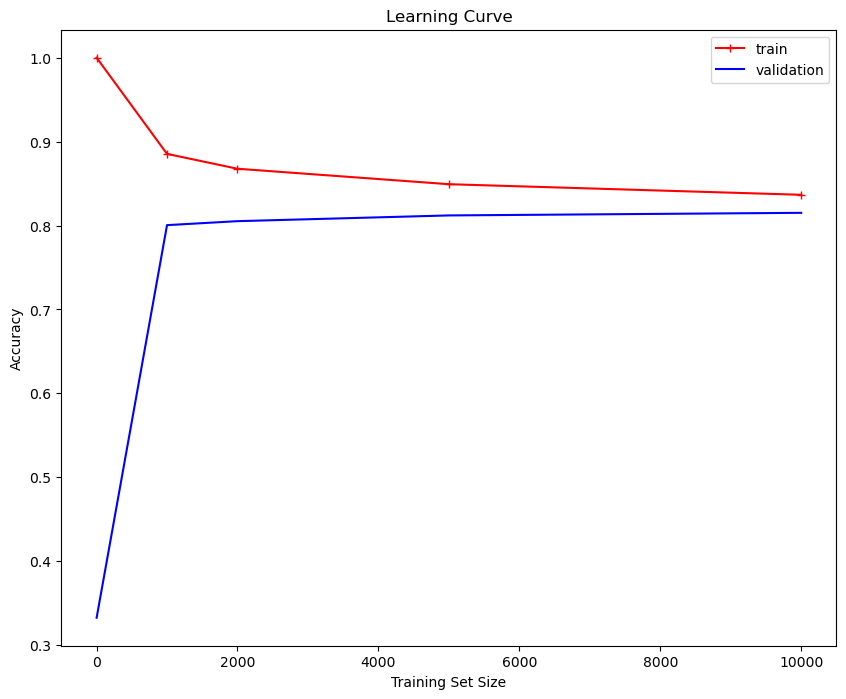

In [23]:
# Plot the learning curve for the Random Forest Classifier.

plot_learning_curve(rfc, [1, 1000, 2000, 5000, 10000], X, y)




Training size: 1
Average Training accuracy: 1.00
Average Testing accuracy:  0.33


Training size: 1000
Average Training accuracy: 0.86
Average Testing accuracy:  0.79


Training size: 2000
Average Training accuracy: 0.82
Average Testing accuracy:  0.80


Training size: 5000
Average Training accuracy: 0.81
Average Testing accuracy:  0.81


Training size: 10000
Average Training accuracy: 0.81
Average Testing accuracy:  0.82


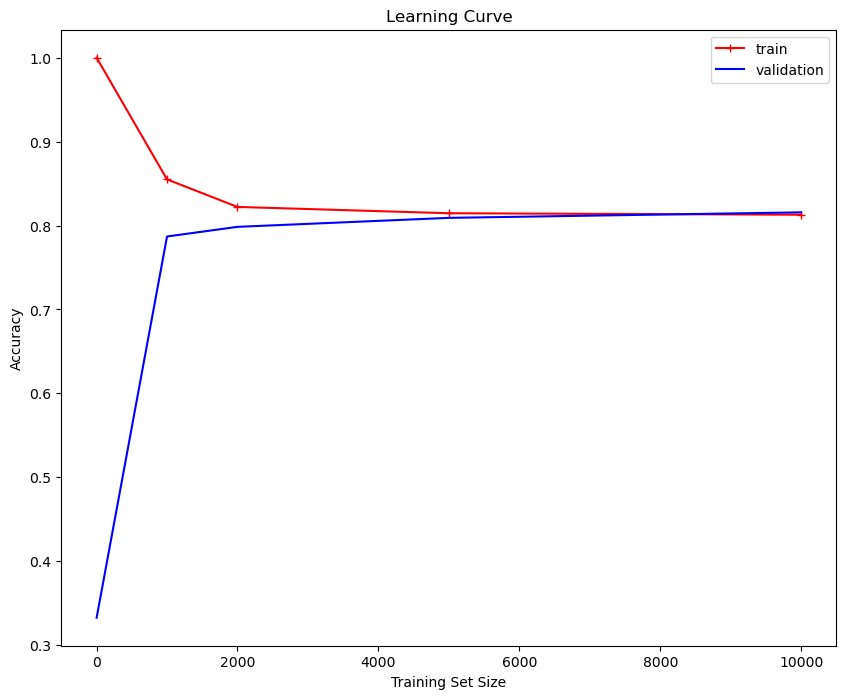

In [24]:
# Plot the learning curve for the Ada Boost Classifier.

plot_learning_curve(abc, [1, 1000, 2000, 5000, 10000], X, y)




Training size: 1
Average Training accuracy: 1.00
Average Testing accuracy:  0.33


Training size: 1000
Average Training accuracy: 0.88
Average Testing accuracy:  0.80


Training size: 2000
Average Training accuracy: 0.86
Average Testing accuracy:  0.81


Training size: 5000
Average Training accuracy: 0.83
Average Testing accuracy:  0.82


Training size: 10000
Average Training accuracy: 0.83
Average Testing accuracy:  0.82


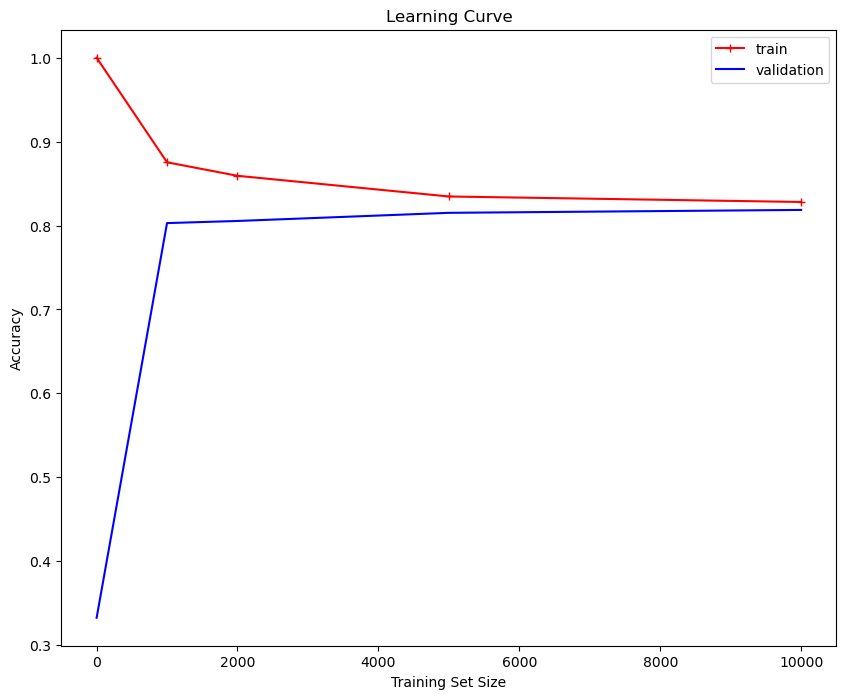

In [25]:
# Plot the learning curve for the Extra Trees Classifier.

plot_learning_curve(etc, [1, 1000, 2000, 5000, 10000], X, y)




Training size: 1
Average Training accuracy: nan
Average Testing accuracy:  nan


Training size: 1000
Average Training accuracy: 0.90
Average Testing accuracy:  0.79


Training size: 2000
Average Training accuracy: 0.88
Average Testing accuracy:  0.80


Training size: 5000
Average Training accuracy: 0.86
Average Testing accuracy:  0.80


Training size: 10000
Average Training accuracy: 0.85
Average Testing accuracy:  0.80


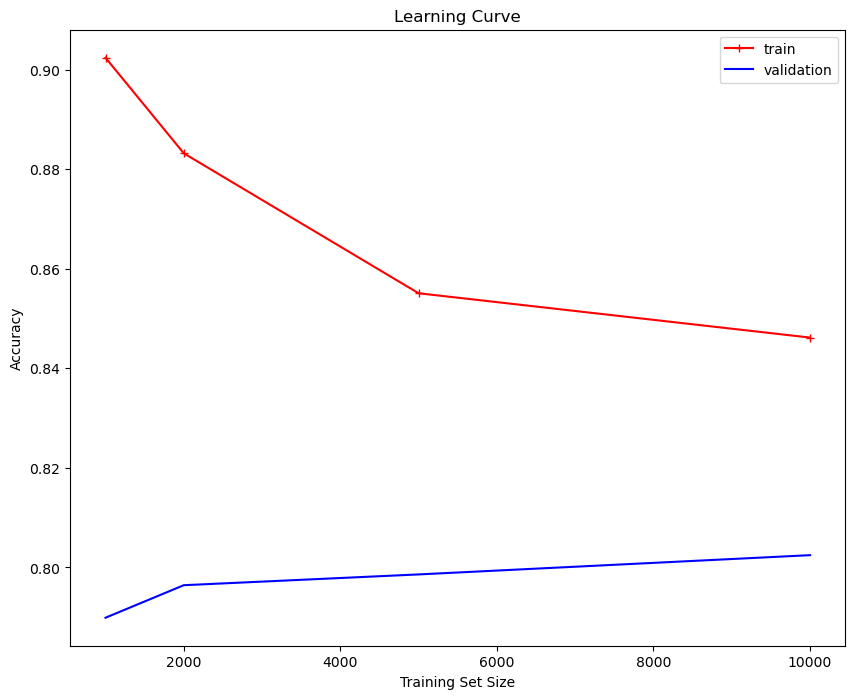

In [26]:
# Plot the learning curve for the Gradient Boosting Classifier.

plot_learning_curve(gbc, [1, 1000, 2000, 5000, 10000], X, y)


#### Question 4 (3 pts)

Discuss and compare the results for the all past three questions. 

* How does changing hyperparms effect model performance? 
* Why do you think certain models performed better/worse? 
* How does this performance line up with known strengths/weakness of these models?

Changing the hyperparameters affect a model's performance as it modifies the structure of the machine learning model and therefore, how a model functions during the training and testing phases. 

Certain hyperparameters can constrain a model, such as the maximum depth in which a Decision Tree Classifer machine learning can grow.  This may or may not improve prediction accuracy as the values of certain hyperparameters may result in a model being overfitted or underfitted.  Therefore, one must experiment with the hyperparameters (i.e., tuning) and evaluate how the model reacts to these changes in order to find the optimal model performance.



The ensemble models seemed to perform slightly better than the single model.  This would be as expected as the ensemble methods combine several models together in the training and prediction phases instead of relying on a single model classifier. 

The bagging ensemble methods, Random Forest and Extra Trees, had the same accuracy as the boosting ensemble methods, Adaptive and Gradient Boosting, at least in this model.

The pros of the ensemble method of machine learning is that several, diverse machine learning methods should theoretically make better predictions and perform better than a single model.

However, some of the cons of the ensemble method could be how long it takes to build the model and how much CPU usage it takes during the process.

For bagging ensemble methods, such as Random Forest and Extra Trees, a couple of the benefits include a reduction of variance in the model as well as reducing the chances of overfitting models.  This improves model performance and reliability of predictions.

For boosting ensemble methods, such as Adaptive and Gradient Boosting, a couple of the benefits include a reduction of the bias in the model as well as reducing the chances of underfitting models.  This improves the accuracy and precision of the model.

The performance of these models seem to hold up in comparison to the single model.
